# 📊 SciPy Statistical Analysis — Exercises 1–8

| Exercise | Topic |
|----------|-------|
| 1 | Basic SciPy usage & version |
| 2 | Descriptive statistics |
| 3 | Normal distribution & plotting |
| 4 | T-test hypothesis testing |
| 5 | Linear regression |
| 6 | ANOVA |
| 7 *(optional)* | Binomial distribution |
| 8 *(optional)* | Pearson & Spearman correlation |


## Global Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy
from scipy import stats
from scipy.stats import (norm, ttest_ind, f_oneway,
                         binom, pearsonr, spearmanr,
                         linregress)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'figure.autolayout': True,
})

np.random.seed(42)
print("All imports successful ✅")


All imports successful ✅


---
## 🌟 Exercise 1 — Basic Usage of SciPy

**Task:** Import SciPy and explore its version and available sub-modules.


In [2]:
import scipy

print("=" * 45)
print("       SciPy Library Information")
print("=" * 45)
print(f"  SciPy version  : {scipy.__version__}")
print(f"  NumPy version  : {np.__version__}")

# Show the main sub-modules available in SciPy
submodules = [
    ("scipy.stats",      "Statistical functions & probability distributions"),
    ("scipy.optimize",   "Optimisation & root-finding"),
    ("scipy.integrate",  "Numerical integration"),
    ("scipy.interpolate","Interpolation"),
    ("scipy.linalg",     "Linear algebra"),
    ("scipy.signal",     "Signal processing"),
    ("scipy.sparse",     "Sparse matrices"),
    ("scipy.special",    "Special mathematical functions"),
    ("scipy.fft",        "Fast Fourier Transforms"),
]

print()
print(f"{'Sub-module':<25} Description")
print("-" * 65)
for mod, desc in submodules:
    print(f"  {mod:<23} {desc}")

# Quick demo: use scipy.constants
from scipy import constants
print(f"\nBonus — scipy.constants:")
print(f"  Speed of light : {constants.c:,.0f} m/s")
print(f"  Planck constant: {constants.h:.4e} J·s")
print(f"  Pi             : {constants.pi:.10f}")


       SciPy Library Information
  SciPy version  : 1.17.1
  NumPy version  : 2.4.4

Sub-module                Description
-----------------------------------------------------------------
  scipy.stats             Statistical functions & probability distributions
  scipy.optimize          Optimisation & root-finding
  scipy.integrate         Numerical integration
  scipy.interpolate       Interpolation
  scipy.linalg            Linear algebra
  scipy.signal            Signal processing
  scipy.sparse            Sparse matrices
  scipy.special           Special mathematical functions
  scipy.fft               Fast Fourier Transforms

Bonus — scipy.constants:
  Speed of light : 299,792,458 m/s
  Planck constant: 6.6261e-34 J·s
  Pi             : 3.1415926536


---
## 🌟 Exercise 2 — Descriptive Statistics

**Task:** Calculate mean, median, variance, and standard deviation for the sample dataset.

```python
data = [12, 15, 13, 12, 18, 20, 22, 21]
```


       Descriptive Statistics Summary
  Data          : [12, 15, 13, 12, 18, 20, 22, 21]
  N (count)     : 8
  ────────────────────────────────────────────
  Mean          : 16.6250
  Median        : 16.5000
  Mode          : 12  (appears 2x)
  ────────────────────────────────────────────
  Variance      : 17.1250  (sample, ddof=1)
  Std Deviation : 4.1382  (sample, ddof=1)
  Std Error     : 1.4631
  ────────────────────────────────────────────
  Minimum       : 12
  Maximum       : 22
  Range         : 10
  ────────────────────────────────────────────
  Skewness      : 0.0653  (right-skewed)
  Kurtosis      : -1.6477


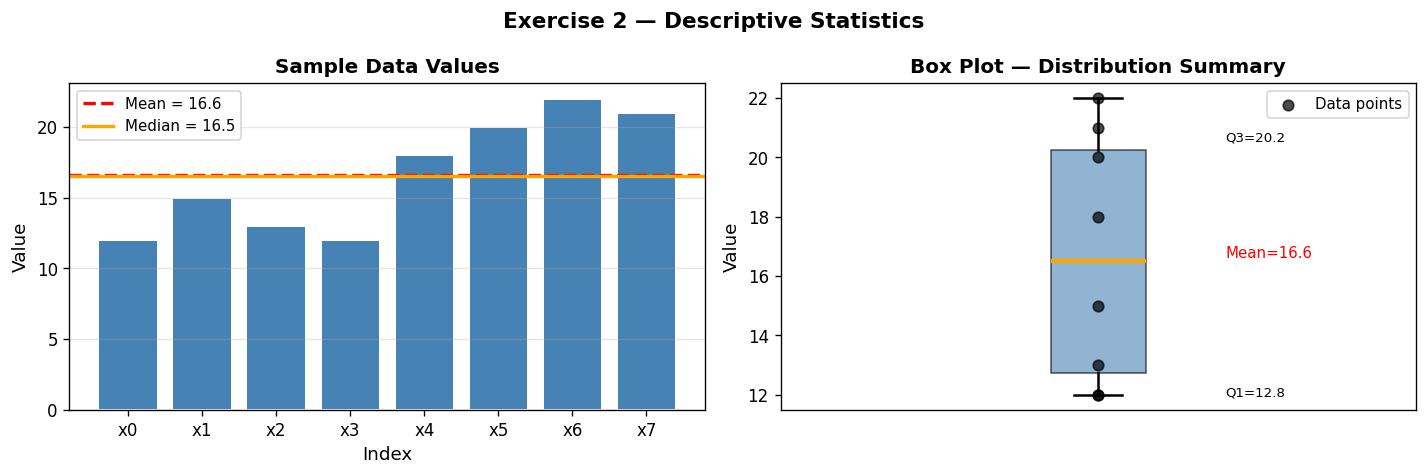


📌 Interpretation:
   Mean (16.6) > Median (16.5) → slight right skew
   The value 12 is the mode (appears twice)
   Std dev = 4.14 means most values fall within ±4.1 of the mean


In [3]:
from scipy import stats as sp_stats

data = [12, 15, 13, 12, 18, 20, 22, 21]

# ── Calculate statistics using SciPy ─────────────────────────────────────────
mean     = np.mean(data)                      # arithmetic average
median   = np.median(data)                    # middle value
variance = sp_stats.tvar(data)                # sample variance (ddof=1)
std_dev  = sp_stats.tstd(data)                # sample std deviation (ddof=1)
mode_res = sp_stats.mode(data, keepdims=True) # most frequent value
skewness = sp_stats.skew(data)                # symmetry measure
kurt     = sp_stats.kurtosis(data)            # tail weight measure
sem      = sp_stats.sem(data)                 # standard error of the mean

print("=" * 50)
print("       Descriptive Statistics Summary")
print("=" * 50)
print(f"  Data          : {data}")
print(f"  N (count)     : {len(data)}")
print(f"  {'─'*44}")
print(f"  Mean          : {mean:.4f}")
print(f"  Median        : {median:.4f}")
print(f"  Mode          : {mode_res.mode[0]}  (appears {mode_res.count[0]}x)")
print(f"  {'─'*44}")
print(f"  Variance      : {variance:.4f}  (sample, ddof=1)")
print(f"  Std Deviation : {std_dev:.4f}  (sample, ddof=1)")
print(f"  Std Error     : {sem:.4f}")
print(f"  {'─'*44}")
print(f"  Minimum       : {min(data)}")
print(f"  Maximum       : {max(data)}")
print(f"  Range         : {max(data) - min(data)}")
print(f"  {'─'*44}")
print(f"  Skewness      : {skewness:.4f}  "
      f"({'right-skewed' if skewness > 0 else 'left-skewed' if skewness < 0 else 'symmetric'})")
print(f"  Kurtosis      : {kurt:.4f}")
print("=" * 50)

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of data values
axes[0].bar(range(len(data)), data, color='steelblue',
            edgecolor='white', linewidth=1.2)
axes[0].axhline(mean,   color='red',    linewidth=2, linestyle='--',
                label=f'Mean = {mean:.1f}')
axes[0].axhline(median, color='orange', linewidth=2, linestyle='-',
                label=f'Median = {median:.1f}')
axes[0].set_title('Sample Data Values')
axes[0].set_xlabel('Index'); axes[0].set_ylabel('Value')
axes[0].set_xticks(range(len(data)))
axes[0].set_xticklabels([f'x{i}' for i in range(len(data))])
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# Box plot showing summary statistics visually
axes[1].boxplot(data, patch_artist=True,
                boxprops={'facecolor':'steelblue','alpha':0.6},
                medianprops={'color':'orange','linewidth':2.5},
                whiskerprops={'linewidth':1.5},
                capprops={'linewidth':1.5},
                flierprops={'marker':'o','markersize':7,'color':'red'})
axes[1].scatter([1]*len(data), data, color='black',
                zorder=5, s=40, alpha=0.7, label='Data points')
axes[1].set_title('Box Plot — Distribution Summary')
axes[1].set_ylabel('Value'); axes[1].set_xticks([])
axes[1].text(1.2, mean, f'Mean={mean:.1f}', color='red', fontsize=9)
axes[1].text(1.2, np.percentile(data,75)+0.3,
             f'Q3={np.percentile(data,75):.1f}', fontsize=8)
axes[1].text(1.2, np.percentile(data,25)-0.8,
             f'Q1={np.percentile(data,25):.1f}', fontsize=8)
axes[1].legend(fontsize=9)

plt.suptitle('Exercise 2 — Descriptive Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Interpretation:")
print(f"   Mean ({mean:.1f}) > Median ({median:.1f}) → slight right skew")
print(f"   The value 12 is the mode (appears twice)")
print(f"   Std dev = {std_dev:.2f} means most values fall within ±{std_dev:.1f} of the mean")


---
## 🌟 Exercise 3 — Normal Distribution

**Task:** Generate a normal distribution (μ=50, σ=10) and plot it.


Normal distribution: N(μ=50, σ=10)
  P(within 1σ) = 0.6827 = 68.27%  (the 68-95-99.7 rule)
  P(within 2σ) = 0.9545 = 95.45%
  P(within 3σ) = 0.9973 = 99.73%

  P(X < 60) = 0.8413  (84.1% of values are below 60)
  P(X > 70) = 0.0228  (2.3% of values exceed 70)
  P(40 < X < 60) = 0.6827


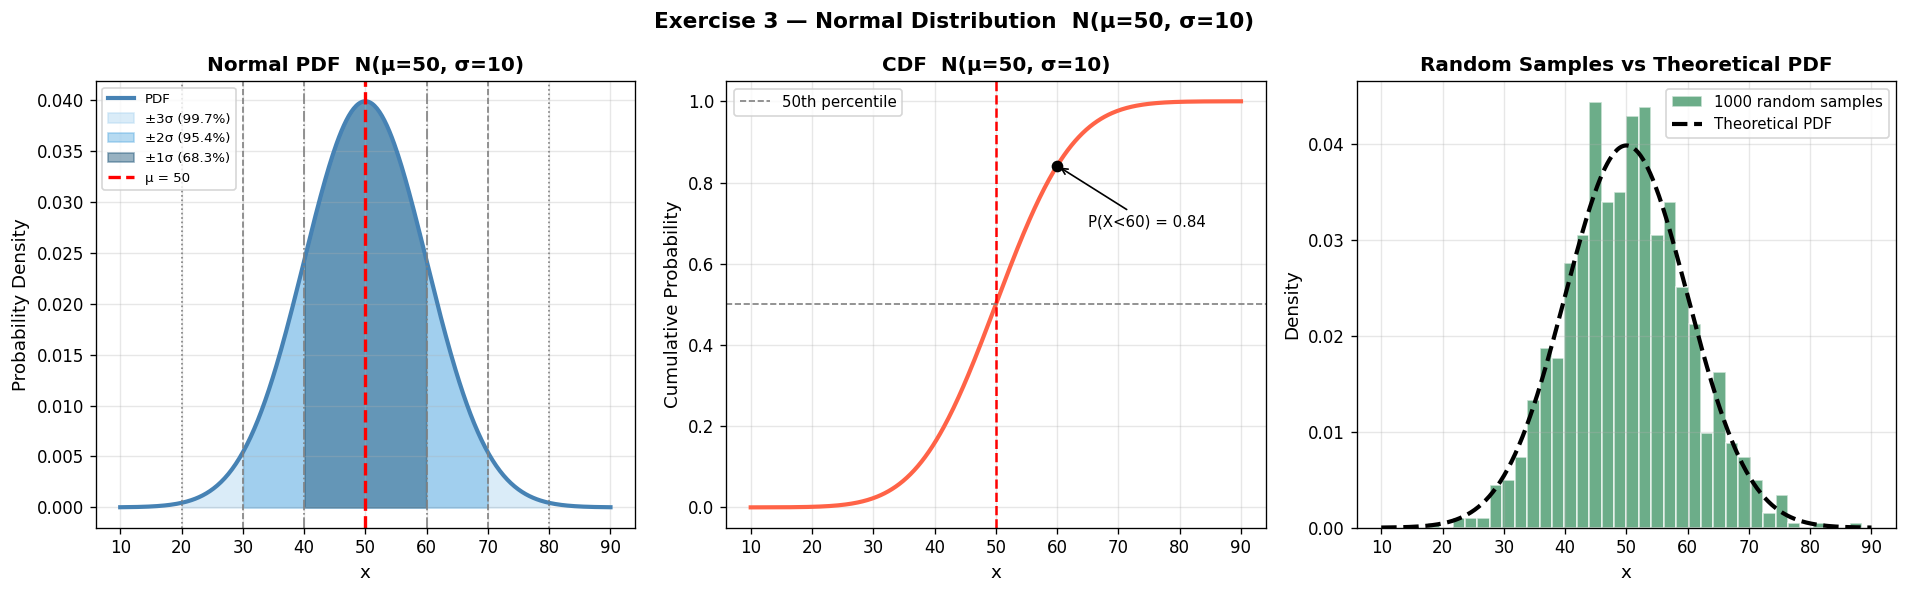

In [4]:
from scipy.stats import norm

mu    = 50    # mean
sigma = 10    # standard deviation

# ── Generate x values spanning ±4 standard deviations ────────────────────────
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

# ── PDF and CDF using SciPy ───────────────────────────────────────────────────
pdf = norm.pdf(x, loc=mu, scale=sigma)   # Probability Density Function
cdf = norm.cdf(x, loc=mu, scale=sigma)   # Cumulative Distribution Function

# ── Key probability values ────────────────────────────────────────────────────
p_within_1sd = norm.cdf(mu + sigma,   mu, sigma) - norm.cdf(mu - sigma,   mu, sigma)
p_within_2sd = norm.cdf(mu + 2*sigma, mu, sigma) - norm.cdf(mu - 2*sigma, mu, sigma)
p_within_3sd = norm.cdf(mu + 3*sigma, mu, sigma) - norm.cdf(mu - 3*sigma, mu, sigma)

print(f"Normal distribution: N(μ={mu}, σ={sigma})")
print(f"  P(within 1σ) = {p_within_1sd:.4f} = {p_within_1sd*100:.2f}%  (the 68-95-99.7 rule)")
print(f"  P(within 2σ) = {p_within_2sd:.4f} = {p_within_2sd*100:.2f}%")
print(f"  P(within 3σ) = {p_within_3sd:.4f} = {p_within_3sd*100:.2f}%")
print(f"\n  P(X < 60) = {norm.cdf(60, mu, sigma):.4f}  (84.1% of values are below 60)")
print(f"  P(X > 70) = {1-norm.cdf(70, mu, sigma):.4f}  (2.3% of values exceed 70)")
print(f"  P(40 < X < 60) = {norm.cdf(60,mu,sigma)-norm.cdf(40,mu,sigma):.4f}")

# ── Plotting ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: PDF with shaded 1σ/2σ/3σ regions
ax = axes[0]
ax.plot(x, pdf, color='steelblue', linewidth=2.5, label='PDF')

shades = [
    (mu-3*sigma, mu+3*sigma, '#AED6F1', '±3σ (99.7%)'),
    (mu-2*sigma, mu+2*sigma, '#5DADE2', '±2σ (95.4%)'),
    (mu-sigma,   mu+sigma,   '#1A5276', '±1σ (68.3%)'),
]
for x1, x2, color, label in shades:
    mask = (x >= x1) & (x <= x2)
    ax.fill_between(x, pdf, where=mask, alpha=0.45, color=color, label=label)

ax.axvline(mu, color='red', linewidth=2, linestyle='--', label=f'μ = {mu}')
for n, ls in zip([1,2,3], ['-.','--',':']):
    ax.axvline(mu + n*sigma, color='gray', linewidth=1, linestyle=ls)
    ax.axvline(mu - n*sigma, color='gray', linewidth=1, linestyle=ls)

ax.set_title(f'Normal PDF  N(μ={mu}, σ={sigma})')
ax.set_xlabel('x'); ax.set_ylabel('Probability Density')
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.3)

# Panel 2: CDF
ax2 = axes[1]
ax2.plot(x, cdf, color='tomato', linewidth=2.5)
ax2.axhline(0.5, color='gray', linewidth=1, linestyle='--', label='50th percentile')
ax2.axvline(mu, color='red', linewidth=1.5, linestyle='--')
# Mark P(X < 60)
x60  = 60
cdf60 = norm.cdf(x60, mu, sigma)
ax2.annotate(f'P(X<{x60}) = {cdf60:.2f}',
             xy=(x60, cdf60), xytext=(x60+5, cdf60-0.15),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9)
ax2.scatter([x60], [cdf60], color='black', zorder=5)
ax2.set_title(f'CDF  N(μ={mu}, σ={sigma})')
ax2.set_xlabel('x'); ax2.set_ylabel('Cumulative Probability')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# Panel 3: Random samples vs theoretical
samples = norm.rvs(loc=mu, scale=sigma, size=1000, random_state=42)
ax3 = axes[2]
ax3.hist(samples, bins=35, density=True, color='seagreen',
         edgecolor='white', alpha=0.7, label='1000 random samples')
ax3.plot(x, pdf, color='black', linewidth=2.5, linestyle='--',
         label='Theoretical PDF')
ax3.set_title('Random Samples vs Theoretical PDF')
ax3.set_xlabel('x'); ax3.set_ylabel('Density')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.suptitle(f'Exercise 3 — Normal Distribution  N(μ={mu}, σ={sigma})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🌟 Exercise 4 — T-Test Application

**Task:** Perform an independent samples t-test on two randomly generated datasets.

```python
data1 = np.random.normal(50, 10, 100)   # mean=50
data2 = np.random.normal(60, 10, 100)   # mean=60
```

**Hypotheses:**
- H₀ (null): The two groups have the same mean (μ₁ = μ₂)
- H₁ (alternative): The means are significantly different (μ₁ ≠ μ₂)


Levene test: stat=0.1804, p=0.6715
  Equal variances: True

Independent Samples T-Test
  Group 1: n=100, mean=48.96, std=9.04
  Group 2: n=100, mean=60.22, std=9.49
  Mean difference: 11.26
  t-statistic: -8.5515
  p-value    : 0.000000
  alpha      : 0.05
  RESULT: REJECT H0 - means are significantly different
  Cohens d: 1.2155 (large effect)


/tmp/ipykernel_743/3203496759.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([data1, data2], patch_artist=True,


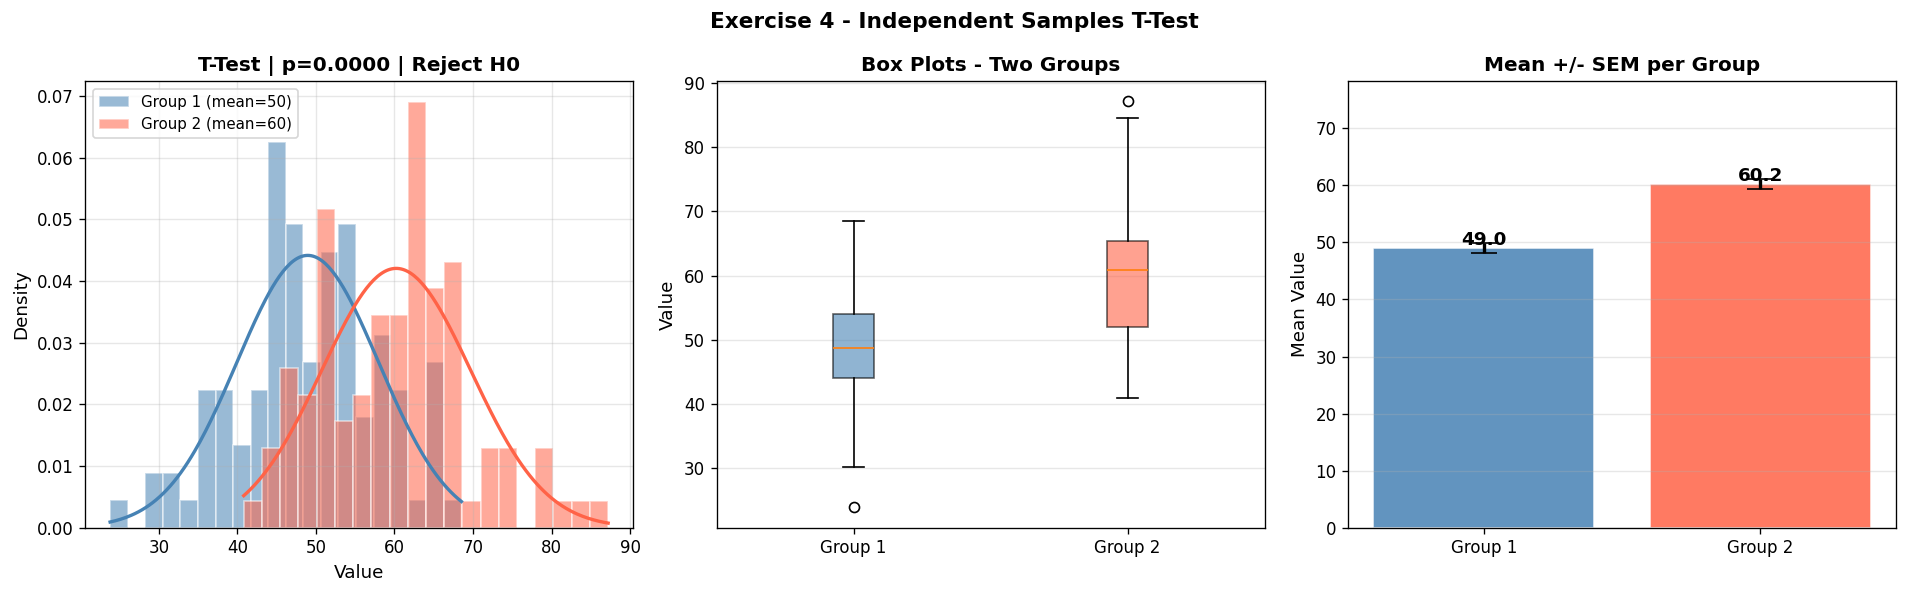

In [5]:
from scipy.stats import ttest_ind, levene

np.random.seed(42)
data1 = np.random.normal(50, 10, 100)
data2 = np.random.normal(60, 10, 100)
alpha = 0.05

# Step 1: Levene test for equal variances
lev_stat, lev_p = levene(data1, data2)
equal_var = lev_p > alpha
print(f"Levene test: stat={lev_stat:.4f}, p={lev_p:.4f}")
print(f"  Equal variances: {equal_var}")

# Step 2: Independent t-test
t_stat, p_value = ttest_ind(data1, data2, equal_var=equal_var)
df_val = len(data1) + len(data2) - 2

print()
print("Independent Samples T-Test")
print("=" * 50)
print(f"  Group 1: n={len(data1)}, mean={data1.mean():.2f}, std={data1.std():.2f}")
print(f"  Group 2: n={len(data2)}, mean={data2.mean():.2f}, std={data2.std():.2f}")
print(f"  Mean difference: {data2.mean()-data1.mean():.2f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value    : {p_value:.6f}")
print(f"  alpha      : {alpha}")
if p_value < alpha:
    print("  RESULT: REJECT H0 - means are significantly different")
else:
    print("  RESULT: FAIL TO REJECT H0 - no significant difference")
print("=" * 50)

# Effect size: Cohen d
pooled_std = np.sqrt((data1.std()**2 + data2.std()**2) / 2)
cohens_d   = (data2.mean() - data1.mean()) / pooled_std
print(f"  Cohens d: {cohens_d:.4f} (large effect)")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: overlapping histograms
for data, label, color in [(data1, "Group 1 (mean=50)", "steelblue"),
                            (data2, "Group 2 (mean=60)", "tomato")]:
    axes[0].hist(data, bins=20, alpha=0.55, color=color,
                 edgecolor="white", label=label, density=True)
    x_range = np.linspace(data.min(), data.max(), 200)
    axes[0].plot(x_range, norm.pdf(x_range, data.mean(), data.std()),
                 color=color, linewidth=2)
result_str = "Reject H0" if p_value < alpha else "Fail to Reject H0"
axes[0].set_title(f"T-Test | p={p_value:.4f} | {result_str}")
axes[0].set_xlabel("Value"); axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Panel 2: box plots
bp = axes[1].boxplot([data1, data2], patch_artist=True,
                labels=["Group 1", "Group 2"])
colors_bp = ["steelblue", "tomato"]
for patch, c in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(c); patch.set_alpha(0.6)
axes[1].set_title("Box Plots - Two Groups")
axes[1].set_ylabel("Value"); axes[1].grid(axis="y", alpha=0.3)

# Panel 3: mean bar chart with error bars
means  = [data1.mean(), data2.mean()]
errors = [data1.std()/np.sqrt(len(data1)), data2.std()/np.sqrt(len(data2))]
bar_colors = ["steelblue", "tomato"]
bars = axes[2].bar(["Group 1", "Group 2"], means, yerr=errors,
                   color=bar_colors, edgecolor="white", capsize=8,
                   error_kw={"linewidth": 2}, alpha=0.85)
for bar, m in zip(bars, means):
    axes[2].text(bar.get_x()+bar.get_width()/2, m+0.5,
                 f"{m:.1f}", ha="center", fontsize=11, fontweight="bold")
axes[2].set_title("Mean +/- SEM per Group")
axes[2].set_ylabel("Mean Value"); axes[2].grid(axis="y", alpha=0.3)
axes[2].set_ylim(0, max(means)*1.3)

plt.suptitle("Exercise 4 - Independent Samples T-Test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 🌟 Exercise 5 — Linear Regression Analysis

**Dataset:**
- `house_sizes`  : [50, 70, 80, 100, 120] m²
- `house_prices` : [150 000, 200 000, 210 000, 250 000, 280 000]

**Questions:**
1. What is the slope and intercept of the regression line?
2. Predict the price of a 90 m² house.
3. Interpret the slope in the context of housing prices.


         Linear Regression Results
  Equation : Price = 1828.77 × Size + (64,383.56)
  Slope    : 1,828.77   ← price increase per 1 m²
  Intercept: 64,383.56  ← theoretical price at size=0
  ─────────────────────────────────────────────────
  r value  : 0.994195  (Pearson correlation)
  r²       : 0.988423  (98.8% of variance explained)
  p-value  : 0.000531  (significant)
  Std Error: 114.2693

  📐 Prediction:
     Size = 90 m²
     Predicted price = 1828.77 × 90 + (64,383.56)
                     = 228,973

  💡 Slope interpretation:
     Each additional square meter increases the price by $1,828.77.
     A 10 m² larger house costs approximately $18,288 more.

  Residuals (actual - predicted):
     50 m²: actual=$150,000  predicted=$155,822  residual=$-5,822
     70 m²: actual=$200,000  predicted=$192,397  residual=$7,603
     80 m²: actual=$210,000  predicted=$210,685  residual=$-685
    100 m²: actual=$250,000  predicted=$247,260  residual=$2,740
    120 m²: actual=$280,000  predict

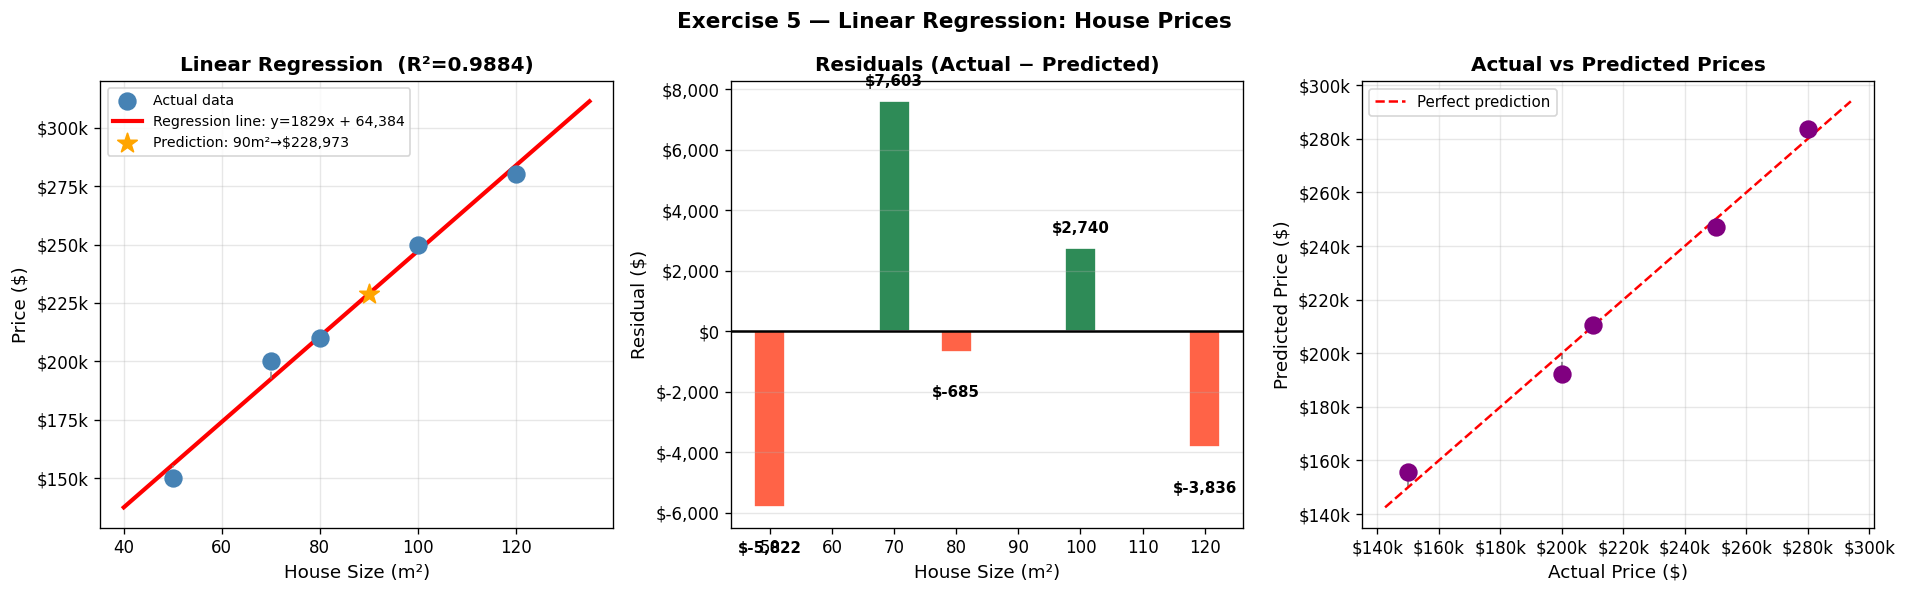

In [6]:
from scipy.stats import linregress

house_sizes  = np.array([50,  70,  80,  100, 120])
house_prices = np.array([150000, 200000, 210000, 250000, 280000])

# ── SciPy linear regression ───────────────────────────────────────────────────
slope, intercept, r_value, p_value, std_err = linregress(house_sizes, house_prices)

print("=" * 55)
print("         Linear Regression Results")
print("=" * 55)
print(f"  Equation : Price = {slope:.2f} × Size + ({intercept:,.2f})")
print(f"  Slope    : {slope:,.2f}   ← price increase per 1 m²")
print(f"  Intercept: {intercept:,.2f}  ← theoretical price at size=0")
print(f"  {'─'*49}")
print(f"  r value  : {r_value:.6f}  (Pearson correlation)")
print(f"  r²       : {r_value**2:.6f}  ({r_value**2*100:.1f}% of variance explained)")
print(f"  p-value  : {p_value:.6f}  ({'significant' if p_value<0.05 else 'not significant'})")
print(f"  Std Error: {std_err:.4f}")
print("=" * 55)

# ── Predict price for 90 m² ───────────────────────────────────────────────────
target_size    = 90
predicted_price = slope * target_size + intercept
print(f"\n  📐 Prediction:")
print(f"     Size = {target_size} m²")
print(f"     Predicted price = {slope:.2f} × {target_size} + ({intercept:,.2f})")
print(f"                     = {predicted_price:,.0f}")
print(f"\n  💡 Slope interpretation:")
print(f"     Each additional square meter increases the price by ${slope:,.2f}.")
print(f"     A 10 m² larger house costs approximately ${slope*10:,.0f} more.")

# ── Residuals ─────────────────────────────────────────────────────────────────
fitted    = slope * house_sizes + intercept
residuals = house_prices - fitted
print(f"\n  Residuals (actual - predicted):")
for size, actual, pred, res in zip(house_sizes, house_prices, fitted, residuals):
    print(f"    {size:3d} m²: actual=${actual:,}  predicted=${pred:,.0f}  residual=${res:,.0f}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Regression line
x_line = np.linspace(40, 135, 200)
y_line = slope * x_line + intercept
axes[0].scatter(house_sizes, house_prices, color='steelblue', s=100,
                zorder=5, label='Actual data')
axes[0].plot(x_line, y_line, color='red', linewidth=2.5,
             label='Regression line: y=' + f'{slope:.0f}' + 'x + ' + f'{intercept:,.0f}')
axes[0].scatter([target_size], [predicted_price], color='orange', s=150,
                zorder=6, marker='*', label=f'Prediction: {target_size}m²→${predicted_price:,.0f}')
# Draw residual lines
for size, actual, pred in zip(house_sizes, house_prices, fitted):
    axes[0].plot([size, size], [actual, pred], color='gray',
                 linewidth=1.2, linestyle='--', alpha=0.7)
axes[0].set_title(f'Linear Regression  (R²={r_value**2:.4f})')
axes[0].set_xlabel('House Size (m²)')
axes[0].set_ylabel('Price ($)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
axes[0].legend(fontsize=8.5); axes[0].grid(alpha=0.3)

# Panel 2: Residual plot
axes[1].bar(house_sizes, residuals, color=['tomato' if r<0 else 'seagreen' for r in residuals],
            edgecolor='white', width=5)
axes[1].axhline(0, color='black', linewidth=1.5)
axes[1].set_title('Residuals (Actual − Predicted)')
axes[1].set_xlabel('House Size (m²)')
axes[1].set_ylabel('Residual ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}'))
for size, res in zip(house_sizes, residuals):
    axes[1].text(size, res + (500 if res >= 0 else -1500),
                 f'${res:,.0f}', ha='center', fontsize=9, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Panel 3: Actual vs Predicted
axes[2].scatter(house_prices, fitted, color='purple', s=100, zorder=5)
for actual, pred in zip(house_prices, fitted):
    axes[2].plot([actual, actual], [actual, pred], 'gray', linewidth=1, linestyle='--')
perfect = np.linspace(house_prices.min()*0.95, house_prices.max()*1.05, 100)
axes[2].plot(perfect, perfect, 'r--', linewidth=1.5, label='Perfect prediction')
axes[2].set_title('Actual vs Predicted Prices')
axes[2].set_xlabel('Actual Price ($)')
axes[2].set_ylabel('Predicted Price ($)')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.suptitle('Exercise 5 — Linear Regression: House Prices',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🌟 Exercise 6 — ANOVA (Analysis of Variance)

**Scenario:** Three fertilizers are applied to plants; growth (cm) is recorded.

**Hypotheses:**
- H₀: All fertilizers produce the same mean growth (μ₁ = μ₂ = μ₃)
- H₁: At least one fertilizer produces a significantly different mean growth


         One-Way ANOVA Results
  Fertilizer 1 : [5, 6, 7, 6, 5]  mean=5.8
  Fertilizer 2 : [7, 8, 7, 9, 8]  mean=7.8
  Fertilizer 3 : [4, 5, 4, 3, 4]  mean=4.0
  ─────────────────────────────────────────────────
  F-statistic  : 28.5263
  p-value      : 0.000028
  α (alpha)    : 0.05
  ─────────────────────────────────────────────────
  ✅ REJECT H₀  (p=0.0000 < α=0.05)
     The fertilizers have SIGNIFICANTLY different effects on growth.

  ANOVA Table:
  Source                SS   df       MS        F
  ──────────────────────────────────────────────────
  Between groups    36.133    2   18.067   28.526
  Within groups      7.600   12    0.633
  Total             43.733   14

  Post-hoc Tukey HSD test (which pairs differ?):
    Fertilizer 1 vs Fertilizer 2: p=0.0049  ✅ Significant
    Fertilizer 1 vs Fertilizer 3: p=0.0099  ✅ Significant
    Fertilizer 2 vs Fertilizer 3: p=0.0000  ✅ Significant

  ❓ What if p-value > 0.05?
     We would FAIL to reject H₀, concluding there is insufficien

/tmp/ipykernel_743/1392457098.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups, patch_artist=True, labels=labels,


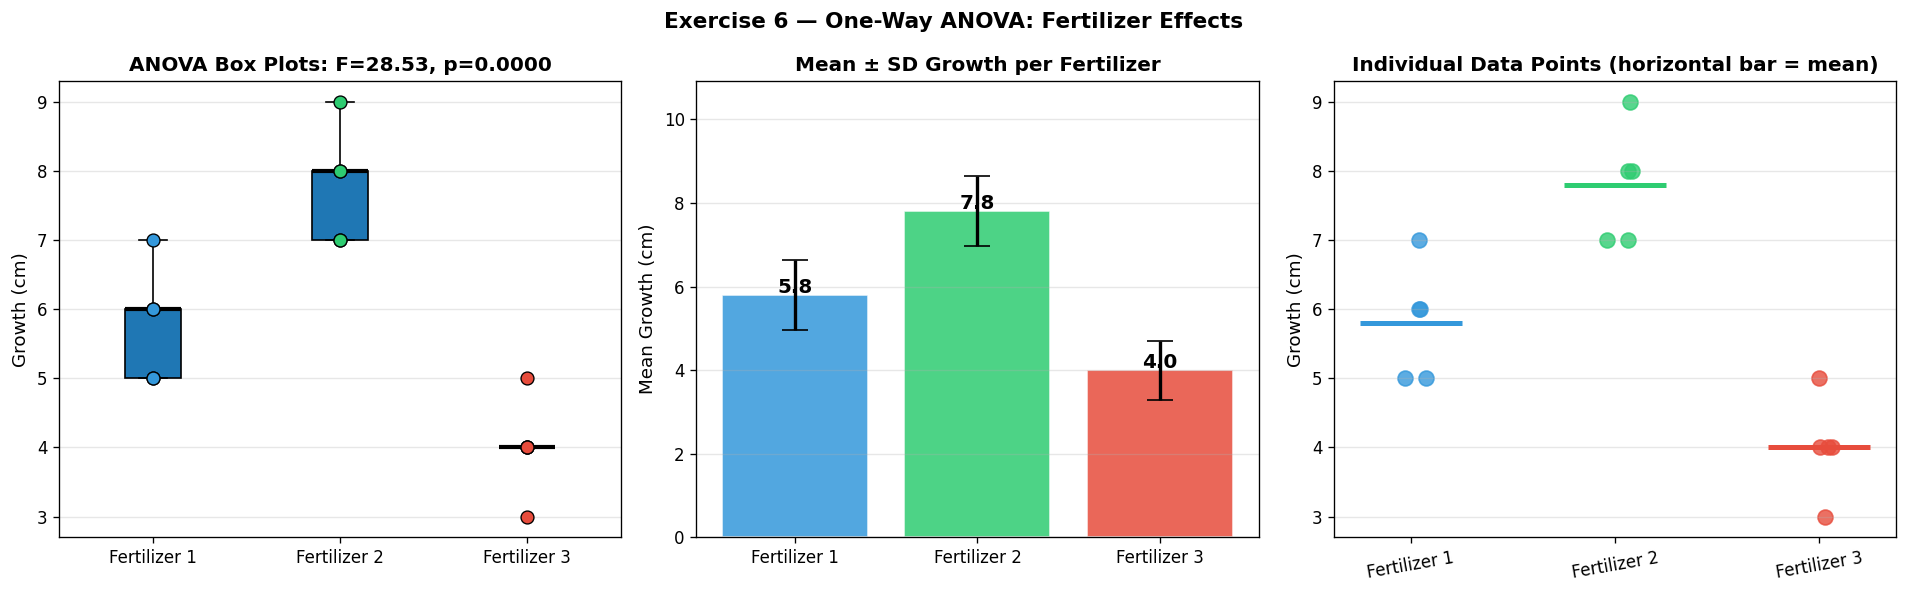

In [7]:
from scipy.stats import f_oneway, tukey_hsd

fertilizer_1 = [5, 6, 7, 6, 5]
fertilizer_2 = [7, 8, 7, 9, 8]
fertilizer_3 = [4, 5, 4, 3, 4]

alpha = 0.05

# ── One-way ANOVA ─────────────────────────────────────────────────────────────
f_stat, p_value = f_oneway(fertilizer_1, fertilizer_2, fertilizer_3)

print("=" * 55)
print("         One-Way ANOVA Results")
print("=" * 55)
print(f"  Fertilizer 1 : {fertilizer_1}  mean={np.mean(fertilizer_1):.1f}")
print(f"  Fertilizer 2 : {fertilizer_2}  mean={np.mean(fertilizer_2):.1f}")
print(f"  Fertilizer 3 : {fertilizer_3}  mean={np.mean(fertilizer_3):.1f}")
print(f"  {'─'*49}")
print(f"  F-statistic  : {f_stat:.4f}")
print(f"  p-value      : {p_value:.6f}")
print(f"  α (alpha)    : {alpha}")
print(f"  {'─'*49}")

if p_value < alpha:
    print(f"  ✅ REJECT H₀  (p={p_value:.4f} < α={alpha})")
    print(f"     The fertilizers have SIGNIFICANTLY different effects on growth.")
else:
    print(f"  ❌ FAIL TO REJECT H₀  (p={p_value:.4f} ≥ α={alpha})")
    print(f"     No significant difference detected between fertilizers.")
print("=" * 55)

# ── Manual ANOVA table ────────────────────────────────────────────────────────
all_data    = fertilizer_1 + fertilizer_2 + fertilizer_3
grand_mean  = np.mean(all_data)
groups      = [fertilizer_1, fertilizer_2, fertilizer_3]
k           = len(groups)      # number of groups
N           = len(all_data)    # total observations

SS_between  = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
SS_within   = sum(sum((x - np.mean(g))**2 for x in g) for g in groups)
SS_total    = sum((x - grand_mean)**2 for x in all_data)

df_between  = k - 1
df_within   = N - k
MS_between  = SS_between / df_between
MS_within   = SS_within  / df_within
F_manual    = MS_between / MS_within

print(f"\n  ANOVA Table:")
print(f"  {'Source':<15} {'SS':>8} {'df':>4} {'MS':>8} {'F':>8}")
print(f"  {'─'*50}")
print(f"  {'Between groups':<15} {SS_between:>8.3f} {df_between:>4} {MS_between:>8.3f} {F_manual:>8.3f}")
print(f"  {'Within groups':<15} {SS_within:>8.3f} {df_within:>4} {MS_within:>8.3f}")
print(f"  {'Total':<15} {SS_total:>8.3f} {N-1:>4}")

# ── Tukey HSD post-hoc (which groups differ?) ─────────────────────────────────
print(f"\n  Post-hoc Tukey HSD test (which pairs differ?):")
tukey = tukey_hsd(fertilizer_1, fertilizer_2, fertilizer_3)
group_names = ['Fertilizer 1', 'Fertilizer 2', 'Fertilizer 3']
for i in range(3):
    for j in range(i+1, 3):
        stat = tukey.statistic[i, j]
        pval = tukey.pvalue[i, j]
        sig  = "✅ Significant" if pval < alpha else "— Not significant"
        print(f"    {group_names[i]} vs {group_names[j]}: "
              f"p={pval:.4f}  {sig}")

print(f"\n  ❓ What if p-value > 0.05?")
print(f"     We would FAIL to reject H₀, concluding there is insufficient")
print(f"     statistical evidence that the fertilizers differ in effectiveness.")
print(f"     This could mean: (a) fertilizers truly have equal effects,")
print(f"     (b) sample size is too small to detect a real difference, or")
print(f"     (c) within-group variability is too high (noisy experiment).")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#3498DB', '#2ECC71', '#E74C3C']
labels = ['Fertilizer 1', 'Fertilizer 2', 'Fertilizer 3']

# Box plot
axes[0].boxplot(groups, patch_artist=True, labels=labels,
                medianprops={'color':'black','linewidth':2.5})
for patch, color in zip(axes[0].findobj(plt.Polygon), colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
for i, (grp, color) in enumerate(zip(groups, colors), 1):
    axes[0].scatter([i]*len(grp), grp, color=color, s=60, zorder=5,
                    edgecolors='black', linewidth=0.8)
axes[0].set_title('ANOVA Box Plots: F=' + f'{f_stat:.2f}' + ', p=' + f'{p_value:.4f}')
axes[0].set_ylabel('Growth (cm)'); axes[0].grid(axis='y', alpha=0.3)

# Mean ± SD bar chart
means = [np.mean(g) for g in groups]
stds  = [np.std(g, ddof=1) for g in groups]
bars  = axes[1].bar(labels, means, yerr=stds, color=colors,
                    edgecolor='white', capsize=8,
                    error_kw={'linewidth':2}, alpha=0.85)
for bar, m in zip(bars, means):
    axes[1].text(bar.get_x()+bar.get_width()/2, m+0.05,
                 f'{m:.1f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Mean ± SD Growth per Fertilizer')
axes[1].set_ylabel('Mean Growth (cm)'); axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, max(means)*1.4)

# Individual data points strip plot
for i, (grp, color, label) in enumerate(zip(groups, colors, labels)):
    x_jitter = np.random.uniform(-0.1, 0.1, len(grp)) + i
    axes[2].scatter(x_jitter, grp, color=color, s=80, alpha=0.8, label=label)
    axes[2].hlines(np.mean(grp), i-0.25, i+0.25, color=color,
                   linewidth=3, linestyle='-')
axes[2].set_xticks([0,1,2]); axes[2].set_xticklabels(labels, rotation=10)
axes[2].set_title('Individual Data Points (horizontal bar = mean)')
axes[2].set_ylabel('Growth (cm)'); axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Exercise 6 — One-Way ANOVA: Fertilizer Effects',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🌟 Exercise 7 (Optional) — Binomial Distribution

**Scenario:** A fair coin is flipped 10 times.  
What is the probability of getting exactly 5 heads? Or at least 7?


       Binomial Distribution  B(n=10, p=0.5)
    k      P(X=k)      P(X≤k)      P(X≥k)
  ────────────────────────────────────────────────
    0    0.000977    0.000977    1.000000
    1    0.009766    0.010742    0.999023
    2    0.043945    0.054688    0.989258
    3    0.117188    0.171875    0.945312
    4    0.205078    0.376953    0.828125
    5    0.246094    0.623047    0.623047 ◄
    6    0.205078    0.828125    0.376953
    7    0.117187    0.945312    0.171875
    8    0.043945    0.989258    0.054688
    9    0.009766    0.999023    0.010742
   10    0.000977    1.000000    0.000977

  Key probabilities:
  P(X = 5)      = 0.246094  (24.61%)
  P(X = 0)      = 0.000977  (0.0977%)
  P(X = 10)     = 0.000977  (0.0977%)
  P(X ≥ 7)      = 0.171875  (17.19%)
  P(X ≤ 3)      = 0.171875  (17.19%)
  P(4 ≤ X ≤ 6)  = 0.656250  (65.62%)

  Expected value : n×p = 5.0 heads
  Std deviation  : √(n×p×q) = 1.5811


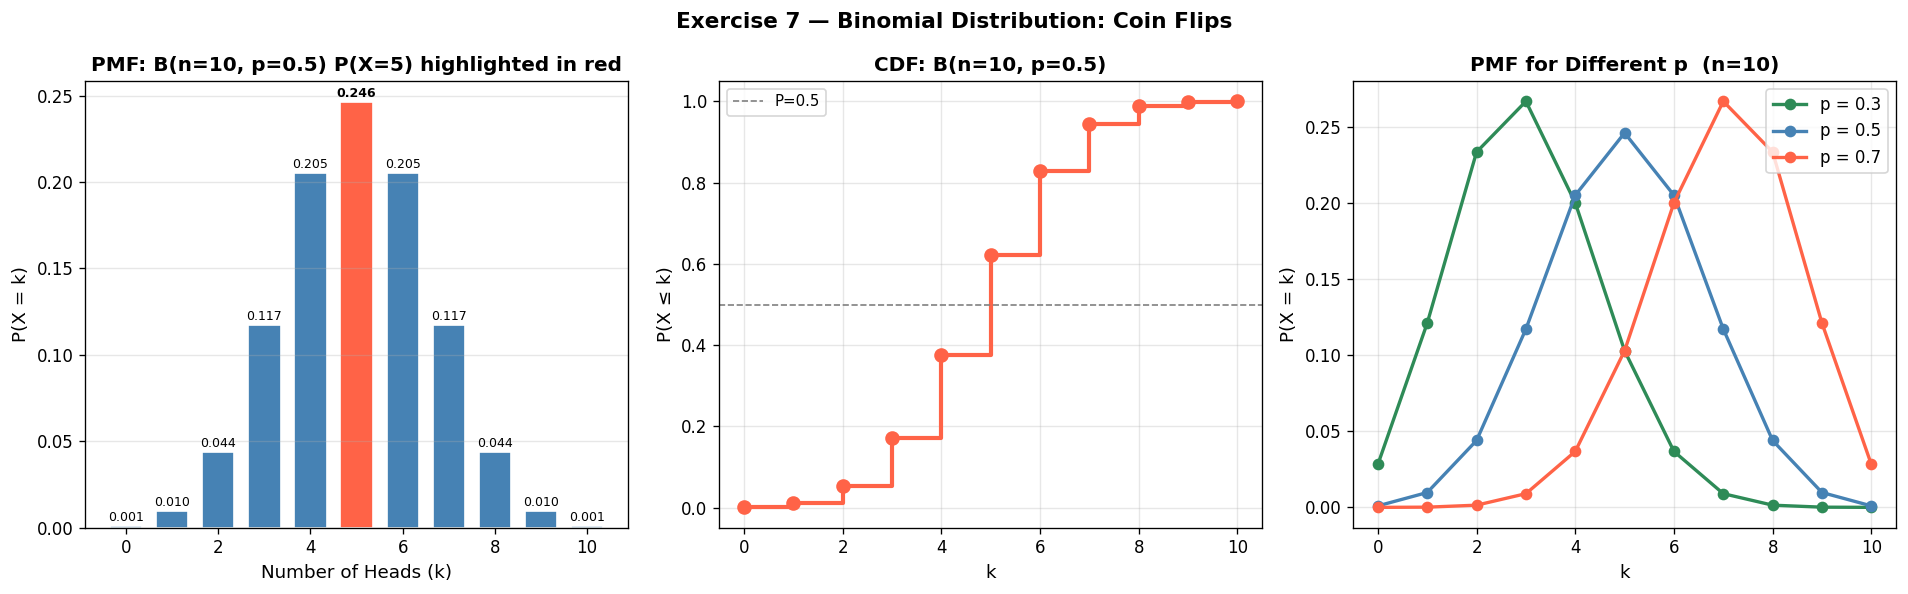

In [8]:
from scipy.stats import binom

n = 10      # number of trials (flips)
p = 0.5     # probability of success (heads)

# ── Probability Mass Function ─────────────────────────────────────────────────
k_values   = np.arange(0, n+1)        # 0, 1, 2, … 10
pmf_values = binom.pmf(k_values, n, p)
cdf_values = binom.cdf(k_values, n, p)

print("=" * 55)
print("       Binomial Distribution  B(n=10, p=0.5)")
print("=" * 55)
print(f"  {'k':>3}  {'P(X=k)':>10}  {'P(X≤k)':>10}  {'P(X≥k)':>10}")
print(f"  {'─'*48}")
for k, pmf, cdf in zip(k_values, pmf_values, cdf_values):
    marker = ' ◄' if k == 5 else ''
    print(f"  {k:>3}  {pmf:>10.6f}  {cdf:>10.6f}  {1-cdf+pmf:>10.6f}{marker}")

print(f"\n  Key probabilities:")
print(f"  P(X = 5)      = {binom.pmf(5,  n, p):.6f}  ({binom.pmf(5,n,p)*100:.2f}%)")
print(f"  P(X = 0)      = {binom.pmf(0,  n, p):.6f}  ({binom.pmf(0,n,p)*100:.4f}%)")
print(f"  P(X = 10)     = {binom.pmf(10, n, p):.6f}  ({binom.pmf(10,n,p)*100:.4f}%)")
print(f"  P(X ≥ 7)      = {1-binom.cdf(6, n, p):.6f}  ({(1-binom.cdf(6,n,p))*100:.2f}%)")
print(f"  P(X ≤ 3)      = {binom.cdf(3,  n, p):.6f}  ({binom.cdf(3,n,p)*100:.2f}%)")
print(f"  P(4 ≤ X ≤ 6)  = {binom.cdf(6,n,p)-binom.cdf(3,n,p):.6f}  ({(binom.cdf(6,n,p)-binom.cdf(3,n,p))*100:.2f}%)")
print(f"\n  Expected value : n×p = {n*p:.1f} heads")
print(f"  Std deviation  : √(n×p×q) = {np.sqrt(n*p*(1-p)):.4f}")

# ── Different p values comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: PMF bar chart for fair coin
colors_bar = ['tomato' if k == 5 else 'steelblue' for k in k_values]
axes[0].bar(k_values, pmf_values, color=colors_bar,
            edgecolor='white', linewidth=1, width=0.7)
axes[0].set_title(f'PMF: B(n={n}, p={p}) P(X=5) highlighted in red')
axes[0].set_xlabel('Number of Heads (k)')
axes[0].set_ylabel('P(X = k)')
for k, v in zip(k_values, pmf_values):
    axes[0].text(k, v+0.003, f'{v:.3f}', ha='center', fontsize=7.5,
                 fontweight='bold' if k==5 else 'normal')
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: CDF
axes[1].step(k_values, cdf_values, where='post', color='tomato', linewidth=2.5)
axes[1].scatter(k_values, cdf_values, color='tomato', s=60, zorder=5)
axes[1].axhline(0.5, color='gray', linewidth=1, linestyle='--', label='P=0.5')
axes[1].set_title(f'CDF: B(n={n}, p={p})')
axes[1].set_xlabel('k'); axes[1].set_ylabel('P(X ≤ k)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# Panel 3: Compare different p values
for prob, color in [(0.3,'seagreen'),(0.5,'steelblue'),(0.7,'tomato')]:
    pmf = binom.pmf(k_values, n, prob)
    axes[2].plot(k_values, pmf, 'o-', color=color, linewidth=2,
                 markersize=6, label=f'p = {prob}')
axes[2].set_title(f'PMF for Different p  (n={n})')
axes[2].set_xlabel('k'); axes[2].set_ylabel('P(X = k)')
axes[2].legend(fontsize=10); axes[2].grid(alpha=0.3)

plt.suptitle('Exercise 7 — Binomial Distribution: Coin Flips',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🌟 Exercise 8 (Optional) — Correlation Coefficients

**Task:** Calculate Pearson and Spearman correlations between age and income.

| Coefficient | Measures | When to use |
|-------------|----------|-------------|
| **Pearson r** | Linear relationship | Both variables normally distributed, no outliers |
| **Spearman ρ** | Monotonic relationship (rank-based) | Non-normal data, ordinal data, outliers present |


Dataset:


,age,income
0,23,35000
1,25,40000
2,30,50000
3,35,60000
4,40,70000



         Correlation Analysis Results
  Coefficient             Value     p-value  Significant?
  ─────────────────────────────────────────────────────
  Pearson r              0.9997      0.0000  ✅ Yes
  Spearman ρ             1.0000      0.0000  ✅ Yes
  Kendall's τ            1.0000      0.0167  ✅ Yes

📌 Interpretation:
   Pearson r = 0.9997 → very strong positive LINEAR correlation
   Spearman ρ = 1.0000 → very strong MONOTONIC correlation (rank-based)

   Both coefficients are very close to 1.0 because the relationship
   between age and income is nearly perfectly linear in this dataset.
   The Pearson and Spearman values are identical here because there
   are no outliers and the data is monotonically increasing.

   Extended dataset (with outlier at age 50 earning $200k):
   Pearson r  = 0.6468  (pulled down by outlier)
   Spearman ρ = 0.9167  (robust to outlier)
   → Spearman is more robust; Pearson is sensitive to outliers.


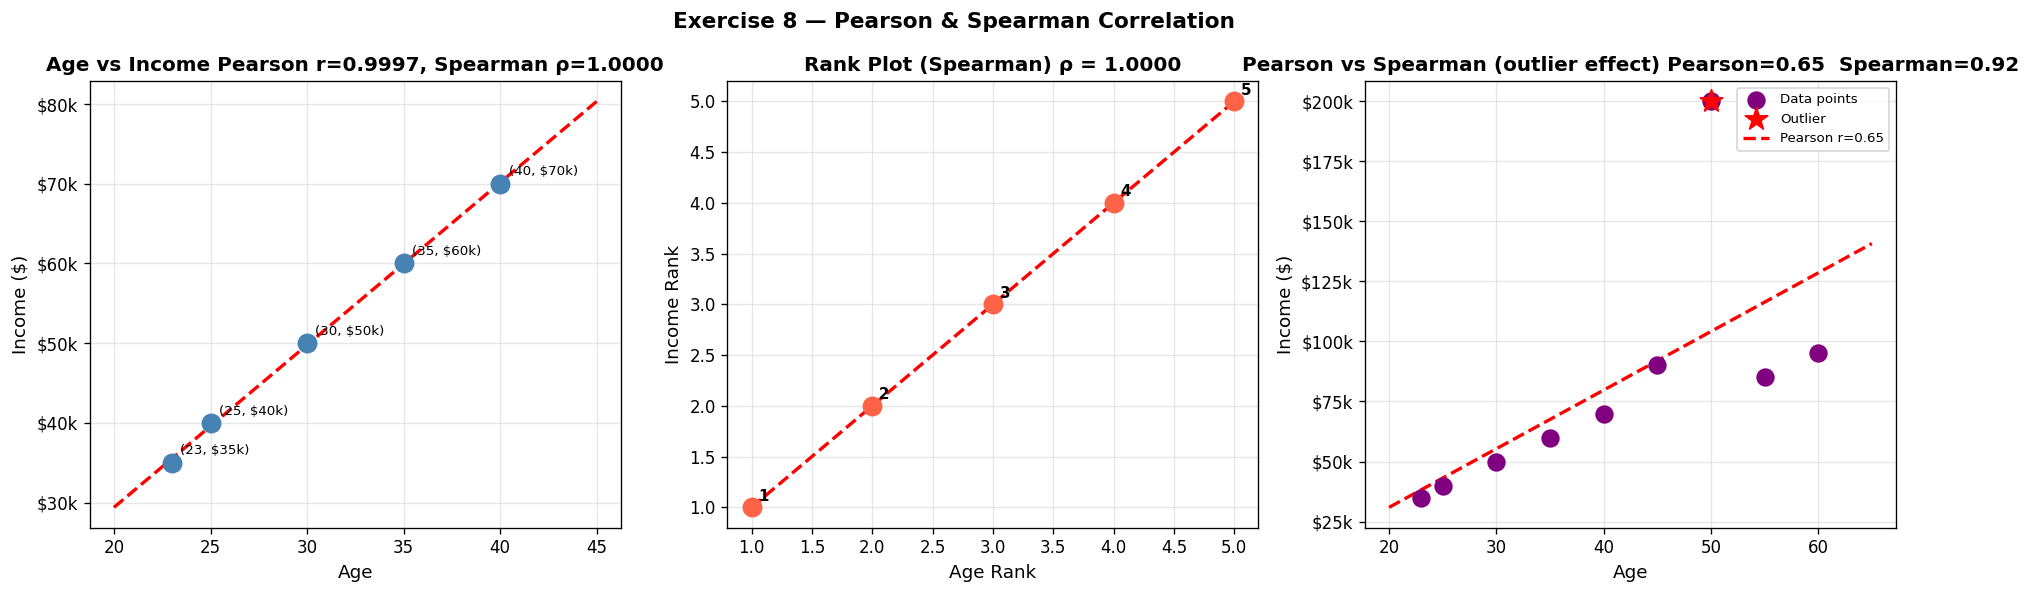

In [9]:
from scipy.stats import pearsonr, spearmanr, kendalltau

data = pd.DataFrame({
    'age'   : [23, 25, 30, 35, 40],
    'income': [35000, 40000, 50000, 60000, 70000]
})

print("Dataset:")
display(data)

# ── Pearson correlation ────────────────────────────────────────────────────────
pearson_r, pearson_p   = pearsonr(data['age'], data['income'])
# ── Spearman correlation ──────────────────────────────────────────────────────
spearman_r, spearman_p = spearmanr(data['age'], data['income'])
# ── Kendall's tau ─────────────────────────────────────────────────────────────
kendall_t, kendall_p   = kendalltau(data['age'], data['income'])

alpha = 0.05

print("\n" + "=" * 55)
print("         Correlation Analysis Results")
print("=" * 55)
print(f"  {'Coefficient':<20} {'Value':>8}  {'p-value':>10}  {'Significant?'}")
print(f"  {'─'*53}")
for name, r, p in [
    ('Pearson r',    pearson_r,  pearson_p),
    ('Spearman ρ',   spearman_r, spearman_p),
    ("Kendall's τ",  kendall_t,  kendall_p),
]:
    sig = '✅ Yes' if p < alpha else '❌ No'
    print(f"  {name:<20} {r:>8.4f}  {p:>10.4f}  {sig}")
print("=" * 55)

# Interpretation
def interpret_r(r):
    a = abs(r)
    if a < 0.1: return 'negligible'
    if a < 0.3: return 'weak'
    if a < 0.5: return 'moderate'
    if a < 0.7: return 'strong'
    return 'very strong'

print(f"\n📌 Interpretation:")
print(f"   Pearson r = {pearson_r:.4f} → {interpret_r(pearson_r)} "
      f"{'positive' if pearson_r > 0 else 'negative'} LINEAR correlation")
print(f"   Spearman ρ = {spearman_r:.4f} → {interpret_r(spearman_r)} "
      f"MONOTONIC correlation (rank-based)")
print(f"\n   Both coefficients are very close to 1.0 because the relationship")
print(f"   between age and income is nearly perfectly linear in this dataset.")
print(f"   The Pearson and Spearman values are identical here because there")
print(f"   are no outliers and the data is monotonically increasing.")

# ── Extended dataset to show difference between Pearson and Spearman ──────────
data_ext = pd.DataFrame({
    'age'    : [23, 25, 30, 35, 40, 45, 50, 55, 60],
    'income' : [35000, 40000, 50000, 60000, 70000, 90000, 200000, 85000, 95000]
})
p_r2, p_p2 = pearsonr(data_ext['age'], data_ext['income'])
s_r2, s_p2 = spearmanr(data_ext['age'], data_ext['income'])
print(f"\n   Extended dataset (with outlier at age 50 earning $200k):")
print(f"   Pearson r  = {p_r2:.4f}  (pulled down by outlier)")
print(f"   Spearman ρ = {s_r2:.4f}  (robust to outlier)")
print(f"   → Spearman is more robust; Pearson is sensitive to outliers.")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Original scatter + regression
axes[0].scatter(data['age'], data['income'], s=120, color='steelblue', zorder=5)
for i, row in data.iterrows():
    axes[0].annotate(f"({int(row['age'])}, ${row['income']/1000:.0f}k)",
                     (row['age'], row['income']),
                     textcoords='offset points', xytext=(5,5), fontsize=8)
m, b = np.polyfit(data['age'], data['income'], 1)
x_line = np.linspace(20, 45, 100)
axes[0].plot(x_line, m*x_line + b, 'r--', linewidth=2)
axes[0].set_title(f'Age vs Income Pearson r={pearson_r:.4f}, Spearman ρ={spearman_r:.4f}')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Income ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
axes[0].grid(alpha=0.3)

# Panel 2: Rank scatter (Spearman operates on ranks)
ages_rank   = data['age'].rank()
income_rank = data['income'].rank()
axes[1].scatter(ages_rank, income_rank, s=120, color='tomato', zorder=5)
for i, (ar, ir) in enumerate(zip(ages_rank, income_rank)):
    axes[1].annotate(f'{i+1}', (ar, ir), textcoords='offset points',
                     xytext=(4,4), fontsize=9, fontweight='bold')
m2, b2 = np.polyfit(ages_rank, income_rank, 1)
axes[1].plot([1,5], [m2+b2, 5*m2+b2], 'r--', linewidth=2)
axes[1].set_title(f'Rank Plot (Spearman) ρ = {spearman_r:.4f}')
axes[1].set_xlabel('Age Rank'); axes[1].set_ylabel('Income Rank')
axes[1].grid(alpha=0.3)

# Panel 3: Outlier comparison
axes[2].scatter(data_ext['age'], data_ext['income'], s=100, color='purple',
                zorder=5, label='Data points')
outlier_idx = data_ext['income'].idxmax()
axes[2].scatter(data_ext.loc[outlier_idx,'age'], data_ext.loc[outlier_idx,'income'],
                s=200, color='red', zorder=6, marker='*', label='Outlier')
m3, b3 = np.polyfit(data_ext['age'], data_ext['income'], 1)
x3 = np.linspace(20, 65, 100)
axes[2].plot(x3, m3*x3+b3, 'r--', linewidth=2,
             label=f'Pearson r={p_r2:.2f}')
axes[2].set_title(f'Pearson vs Spearman (outlier effect) Pearson={p_r2:.2f}  Spearman={s_r2:.2f}')
axes[2].set_xlabel('Age'); axes[2].set_ylabel('Income ($)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle('Exercise 8 — Pearson & Spearman Correlation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📋 Summary — SciPy Functions Used

| Exercise | SciPy Function | Purpose |
|----------|---------------|---------|
| 2 | `scipy.stats.tvar()`, `tstd()`, `mode()`, `skew()`, `sem()` | Descriptive statistics |
| 3 | `scipy.stats.norm.pdf()`, `.cdf()`, `.rvs()` | Normal distribution |
| 4 | `scipy.stats.ttest_ind()`, `levene()` | Independent samples t-test |
| 5 | `scipy.stats.linregress()` | Linear regression |
| 6 | `scipy.stats.f_oneway()`, `tukey_hsd()` | ANOVA + post-hoc test |
| 7 | `scipy.stats.binom.pmf()`, `.cdf()` | Binomial probabilities |
| 8 | `scipy.stats.pearsonr()`, `spearmanr()`, `kendalltau()` | Correlation coefficients |

### Key concepts reviewed

- **Descriptive statistics** describe the centre, spread, and shape of data
- **Normal distribution** is defined by μ and σ; the 68-95-99.7 rule applies
- **T-test** compares means of two groups; requires checking variance equality first
- **Linear regression** models a linear relationship; R² measures fit quality
- **ANOVA** extends t-test to 3+ groups; post-hoc tests identify which pairs differ
- **Binomial distribution** models the number of successes in n independent trials
- **Pearson r** measures linear correlation; **Spearman ρ** is rank-based and robust to outliers
